# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [1]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [2]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?


**1.2:**  How will your solution be used?


**1.3:**  How should success (or failure) be measured?


## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [3]:
# Look at the first few rows
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [4]:
# Percentage of missing values per column
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_pct.sort_values(ascending=False)

buildingclasstypeid             99.98
finishedsquarefeet13            99.95
storytypeid                     99.94
basementsqft                    99.94
yardbuildingsqft26              99.91
fireplaceflag                   99.78
architecturalstyletypeid        99.73
typeconstructiontypeid          99.71
finishedsquarefeet6             99.50
pooltypeid10                    99.40
decktypeid                      99.21
poolsizesum                     98.88
pooltypeid2                     98.62
hashottuborspa                  98.02
yardbuildingsqft17              96.92
taxdelinquencyflag              96.26
taxdelinquencyyear              96.26
finishedsquarefeet15            96.10
finishedsquarefeet50            92.22
finishedfloor1squarefeet        92.22
fireplacecnt                    89.32
threequarterbathnbr             86.98
pooltypeid7                     80.57
poolcnt                         79.16
numberofstories                 77.32
airconditioningtypeid           67.78
garagetotals

In [5]:
# Number of unique values per column
df.nunique()

parcelid                        77414
airconditioningtypeid               5
architecturalstyletypeid            5
basementsqft                       43
bathroomcnt                        22
bedroomcnt                         16
buildingclasstypeid                 2
buildingqualitytypeid              12
calculatedbathnbr                  21
decktypeid                          1
finishedfloor1squarefeet         1787
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
finishedsquarefeet13               13
finishedsquarefeet15             1724
finishedsquarefeet50             1807
finishedsquarefeet6               350
fips                                3
fireplacecnt                        5
fullbathcnt                        13
garagecarcnt                       14
garagetotalsqft                   839
hashottuborspa                      1
heatingorsystemtypeid              10
latitude                        64038
longitude                       62461
lotsizesquar

In [6]:
# Summary of columns: types, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

hashottuborspa, propertycountylandusecode, propertyzoningdesc, fireplaceflag, taxdelinquencyflag

Additionally, several numeric columns are really categorical IDs (not meaningful as continuous values):

parcelid, fips, airconditioningtypeid, architecturalstyletypeid, buildingclasstypeid, buildingqualitytypeid, heatingorsystemtypeid, propertylandusetypeid, storytypeid, typeconstructiontypeid, regionidcity, regionidcounty, regionidneighborhood regionidzip, assessmentyear, pooltypeid10, pooltypeid2, pooltypeid7

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly.

* parcelid — just a unique row identifier, no predictive value
* rawcensustractandblock and censustractandblock — these are geographic codes that are essentially unique per property;
  location is already captured by latitude/longitude and the regionid* columns
* assessmentyear — has only 1 unique value (2016), so it provides zero information

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example.

Features with >95% missing are essentially useless since there's too little data to learn from:

buildingclasstypeid (99.98%), finishedsquarefeet13 (99.95%), storytypeid (99.94%), basementsqft (99.94%), yardbuildingsqft26 (99.91%), fireplaceflag (99.78%), architecturalstyletypeid (99.73%), typeconstructiontypeid (99.71%), finishedsquarefeet6 (99.50%), pooltypeid10 (99.40%), decktypeid (99.21%), poolsizesum (98.88%), pooltypeid2 (98.62%), hashottuborspa (98.02%), yardbuildingsqft17 (96.92%), taxdelinquencyflag/taxdelinquencyyear (96.26%), finishedsquarefeet15 (96.10%)

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example.

Features with only 1 unique value provide no discriminating information:

decktypeid, hashottuborspa, poolcnt, pooltypeid10, pooltypeid2, pooltypeid7, storytypeid, fireplaceflag, assessmentyear, taxdelinquencyflag — these are essentially binary flags where only one value exists (the rest are NaN)

Also assessmentyear has 1 unique value (2016) — constant across all rows.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

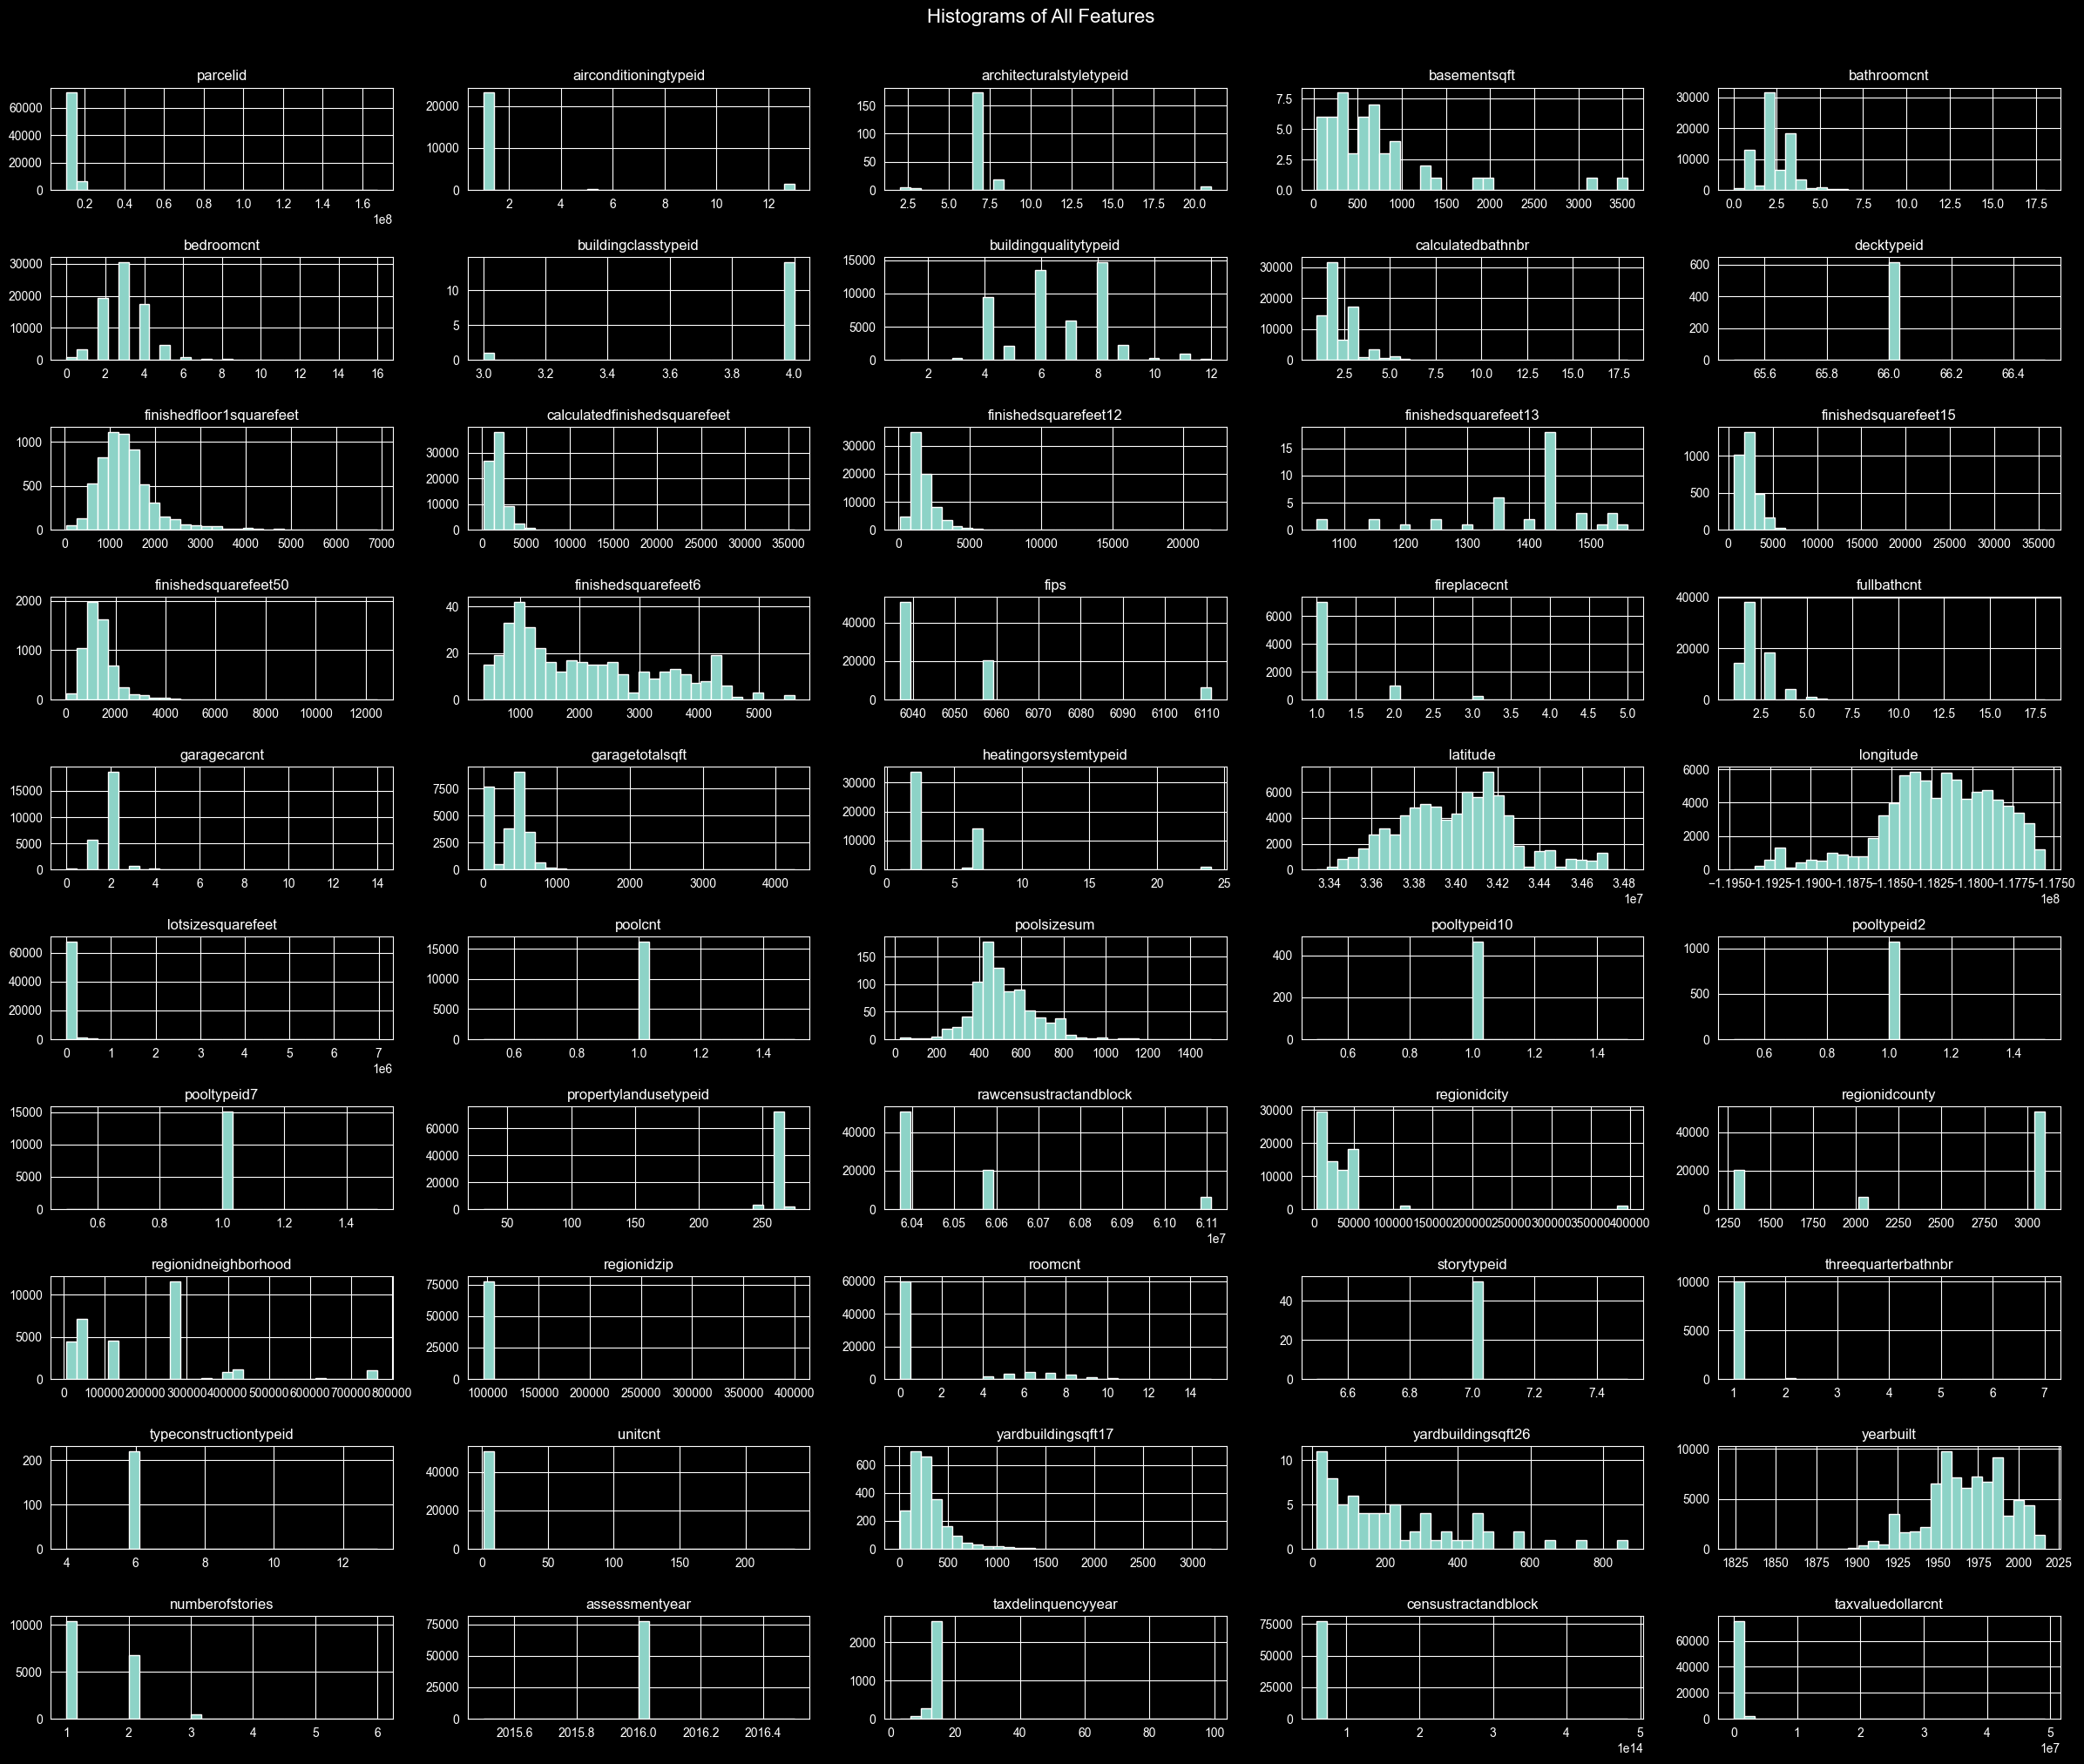

In [7]:
# Overview: histograms for all features
df.hist(figsize=(24, 20), bins=30, layout=(-1, 5))
plt.suptitle("Histograms of All Features", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

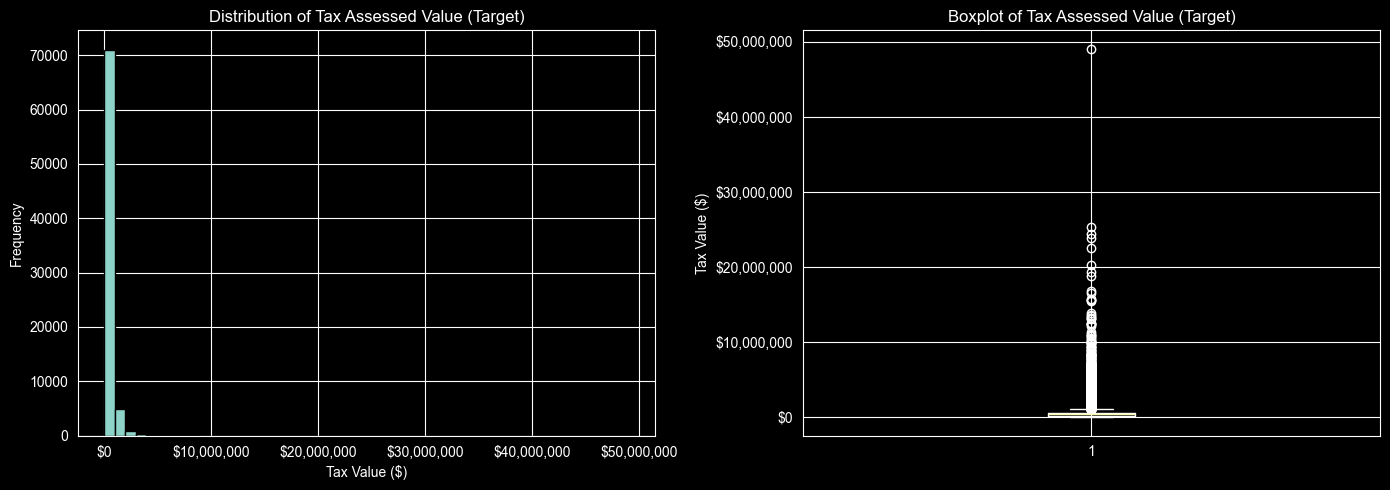

In [8]:
# Feature 1: Target variable - taxvaluedollarcnt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['taxvaluedollarcnt'].dropna(), bins=50, edgecolor='black')
axes[0].set_title('Distribution of Tax Assessed Value (Target)')
axes[0].set_xlabel('Tax Value ($)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

axes[1].boxplot(df['taxvaluedollarcnt'].dropna(), vert=True)
axes[1].set_title('Boxplot of Tax Assessed Value (Target)')
axes[1].set_ylabel('Tax Value ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

plt.tight_layout()
plt.show()

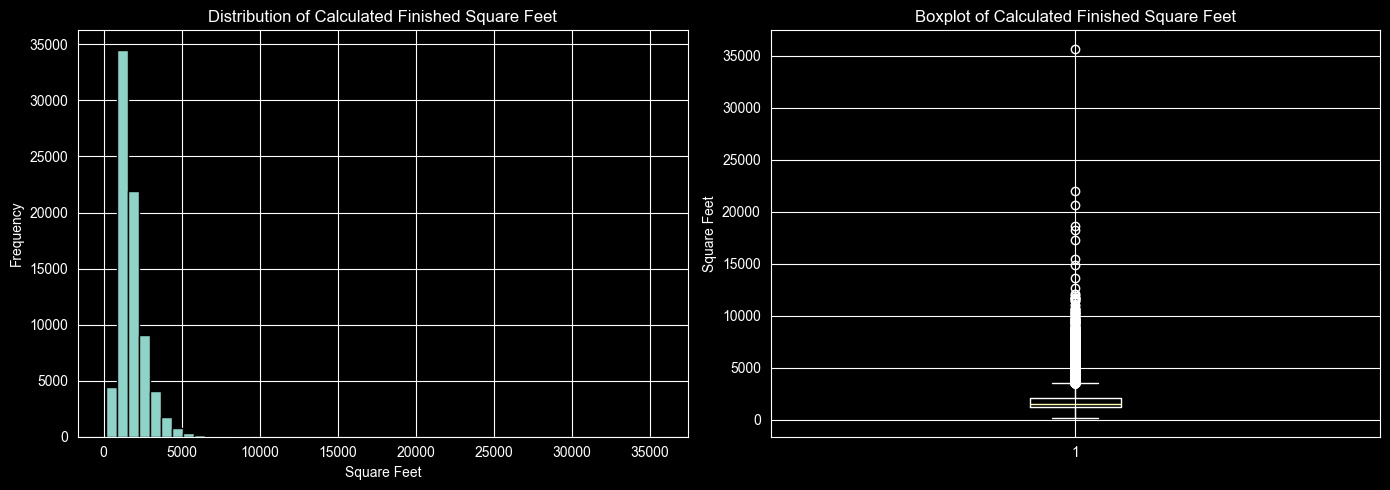

In [9]:
# Feature 2: calculatedfinishedsquarefeet - likely strong predictor of home value
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['calculatedfinishedsquarefeet'].dropna(), bins=50, edgecolor='black')
axes[0].set_title('Distribution of Calculated Finished Square Feet')
axes[0].set_xlabel('Square Feet')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['calculatedfinishedsquarefeet'].dropna(), vert=True)
axes[1].set_title('Boxplot of Calculated Finished Square Feet')
axes[1].set_ylabel('Square Feet')

plt.tight_layout()
plt.show()

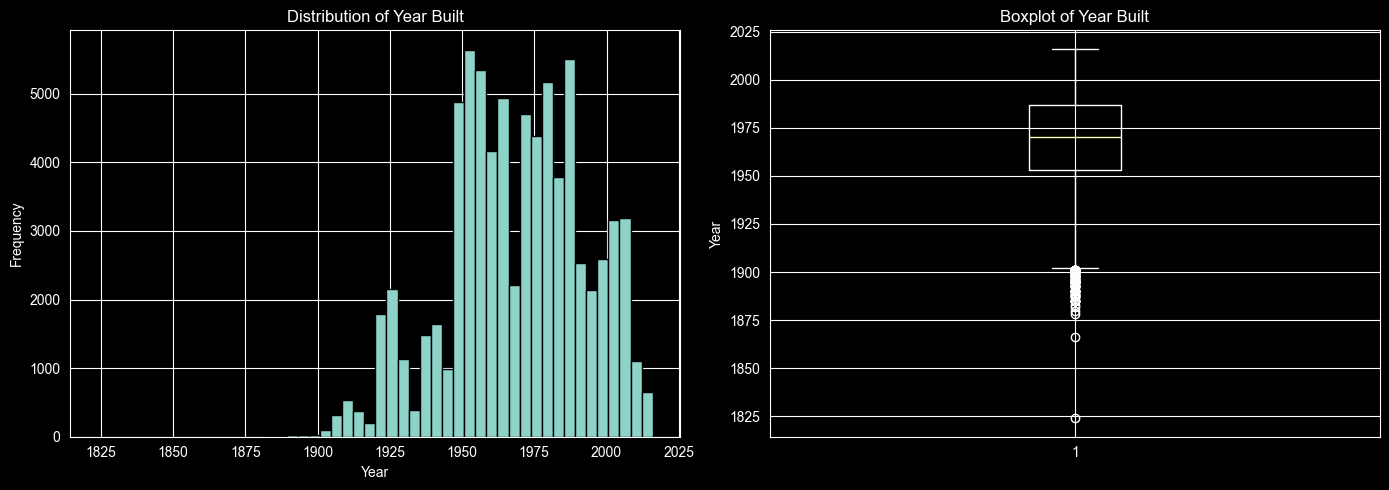

In [10]:
# Feature 3: yearbuilt - age of home may influence value
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['yearbuilt'].dropna(), bins=50, edgecolor='black')
axes[0].set_title('Distribution of Year Built')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['yearbuilt'].dropna(), vert=True)
axes[1].set_title('Boxplot of Year Built')
axes[1].set_ylabel('Year')

plt.tight_layout()
plt.show()

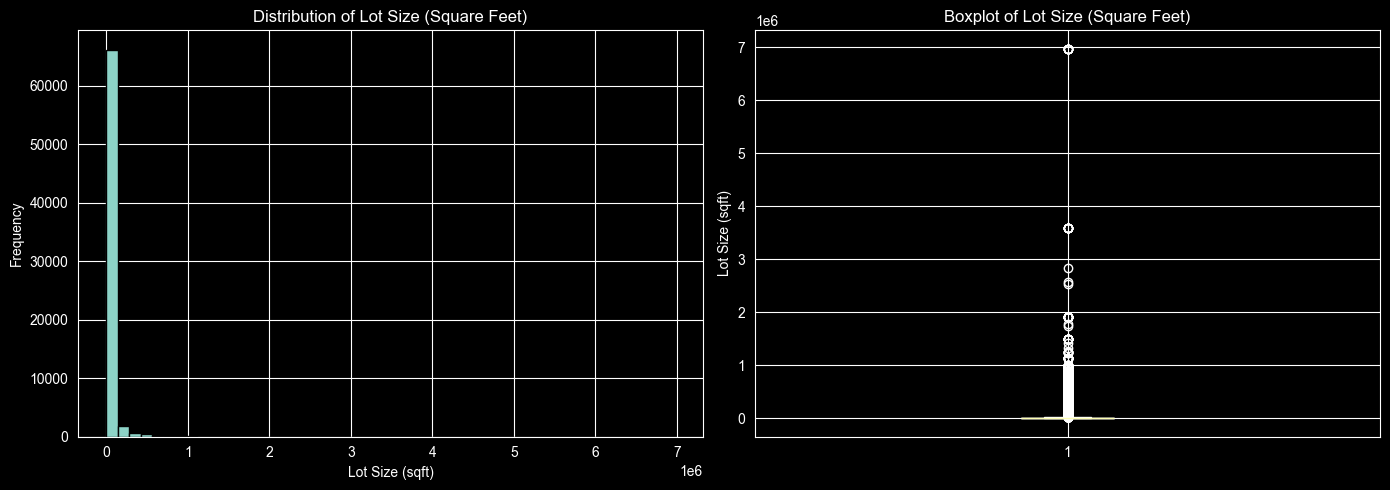

In [11]:
# Feature 4: lotsizesquarefeet - lot size likely influences property value
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['lotsizesquarefeet'].dropna(), bins=50, edgecolor='black')
axes[0].set_title('Distribution of Lot Size (Square Feet)')
axes[0].set_xlabel('Lot Size (sqft)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['lotsizesquarefeet'].dropna(), vert=True)
axes[1].set_title('Boxplot of Lot Size (Square Feet)')
axes[1].set_ylabel('Lot Size (sqft)')

plt.tight_layout()
plt.show()

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?

Distribution:
* taxvaluedollarcnt: Exponential/log-normal distribution — heavily right-skewed (skewness = 14.43) with a long tail of high-value properties. Most values cluster below $600K.
* calculatedfinishedsquarefeet: Right-skewed (skewness = 3.30), roughly log-normal. The bulk of homes fall between 1,000–2,500 sqft with a long tail of very large properties.
* yearbuilt: Approximately normal, slightly left-skewed (skewness = -0.31), centered around 1970. The most symmetric of the four features.
* lotsizesquarefeet: Extremely right-skewed (skewness = 25.15), resembling an exponential distribution. The median is ~7,200 sqft but the max is nearly 7 million.

Problems:
* All four features have outliers, but taxvaluedollarcnt and lotsizesquarefeet are the worst — their means are 1.4x and 4x their medians respectively, indicating extreme upper outliers that will distort models. The target max ($49M) is ~137x the median ($359K), and lot size max (7M sqft) is ~970x the median (7.2K sqft). These will likely need capping or log-transforming.
* yearbuilt has a few properties dating back to the 1800s which may be data entry errors or genuinely historic homes.

Why these features / anything interesting:
* taxvaluedollarcnt is the target — understanding its distribution is essential for choosing the right model and loss function. The heavy skew suggests we should consider predicting log(value) instead.
* calculatedfinishedsquarefeet was chosen because square footage is typically the single strongest predictor of home price, and with only 0.3% missing it's one of the most complete features.
* yearbuilt was chosen because it reflects the Southern California post-war housing boom (1950s–1970s peak), and home age often correlates with both value and condition.
* lotsizesquarefeet was chosen because its extreme skew (the worst of any feature) highlights a likely mix of standard residential parcels and large agricultural/ranch properties — these may need to be treated separately or capped.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [ ]:
# Drop features unsuitable for regression (NOT due to missing values)
drop_unsuitable = [
    'parcelid',                   # Unique ID, no predictive value
    'assessmentyear',             # Only 1 unique value (2016), provides no information
    'rawcensustractandblock',     # Nearly unique per property, redundant with lat/long and regionid columns
    'censustractandblock',        # Same as above
    'fips',                       # Redundant with regionidcounty (identical groupings)
    'propertycountylandusecode',  # Text-based land use code, redundant with propertylandusetypeid
    'propertyzoningdesc',         # 1,907 unique text values — too high cardinality to encode meaningfully
]

df1 = df.drop(columns=drop_unsuitable)
print(f"Dropped {len(drop_unsuitable)} features: {df.shape[1]} -> {df1.shape[1]} columns")
print(f"Dropped: {drop_unsuitable}")

#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop.

We dropped 7 features that are unsuitable for regression for the following reasons. `parcelid` is a unique row identifier with no predictive meaning. `assessmentyear` is constant (2016 for every row), so it carries zero information. `rawcensustractandblock` and `censustractandblock` are near-unique geographic codes (39K+ unique values each) that are redundant with `latitude`, `longitude`, and the `regionid` columns which capture location more usefully. `fips` is redundant with `regionidcounty` — both have exactly 3 values with identical group sizes, so keeping both would duplicate the same information. `propertycountylandusecode` is a text-based land use code that overlaps with `propertylandusetypeid` (a cleaner numeric version with only 13 categories vs. 75 text codes). Finally, `propertyzoningdesc` has 1,907 unique text values — far too high cardinality to encode meaningfully without extensive domain-specific feature engineering, and zoning information is partially captured by the land use type and location features.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [14]:
# Drop features with too many missing values (>80% null)
missing_pct1 = (df1.isnull().sum() / len(df1) * 100).round(2)

threshold = 80.0
drop_missing = missing_pct1[missing_pct1 > threshold].index.tolist()

print(f"Features with >{threshold}% missing ({len(drop_missing)} features):")
for col in missing_pct1[missing_pct1 > threshold].sort_values(ascending=False).index:
    print(f"  {col}: {missing_pct1[col]}%")

df2 = df1.drop(columns=drop_missing)
print(f"\nDropped {len(drop_missing)} features: {df1.shape[1]} -> {df2.shape[1]} columns")

Features with >80.0% missing (23 features):
  buildingclasstypeid: 99.98%
  finishedsquarefeet13: 99.95%
  basementsqft: 99.94%
  storytypeid: 99.94%
  yardbuildingsqft26: 99.91%
  fireplaceflag: 99.78%
  architecturalstyletypeid: 99.73%
  typeconstructiontypeid: 99.71%
  finishedsquarefeet6: 99.5%
  pooltypeid10: 99.4%
  decktypeid: 99.21%
  poolsizesum: 98.88%
  pooltypeid2: 98.62%
  hashottuborspa: 98.02%
  yardbuildingsqft17: 96.92%
  taxdelinquencyflag: 96.26%
  taxdelinquencyyear: 96.26%
  finishedsquarefeet15: 96.1%
  finishedsquarefeet50: 92.22%
  finishedfloor1squarefeet: 92.22%
  fireplacecnt: 89.32%
  threequarterbathnbr: 86.98%
  pooltypeid7: 80.57%

Dropped 23 features: 48 -> 25 columns


In [15]:
# Check remaining missing values
remaining_missing = (df2.isnull().sum() / len(df2) * 100).round(2)
print("Remaining features with missing values:")
for col, pct in remaining_missing[remaining_missing > 0].sort_values(ascending=False).items():
    print(f"  {col}: {pct}%")

Remaining features with missing values:
  poolcnt: 79.16%
  numberofstories: 77.32%
  airconditioningtypeid: 67.78%
  garagetotalsqft: 67.12%
  garagecarcnt: 67.12%
  regionidneighborhood: 60.09%
  heatingorsystemtypeid: 36.13%
  buildingqualitytypeid: 35.82%
  unitcnt: 34.67%
  lotsizesquarefeet: 10.68%
  finishedsquarefeet12: 4.75%
  regionidcity: 1.94%
  fullbathcnt: 0.84%
  calculatedbathnbr: 0.84%
  yearbuilt: 0.39%
  calculatedfinishedsquarefeet: 0.3%
  regionidzip: 0.11%
  taxvaluedollarcnt: 0.05%
  regionidcounty: 0.04%
  propertylandusetypeid: 0.04%
  roomcnt: 0.04%
  bathroomcnt: 0.04%
  latitude: 0.04%
  bedroomcnt: 0.04%
  longitude: 0.04%


#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped

We chose a threshold of 80% missing values. Features above this threshold have so few non-null observations that any imputation would be unreliable and dominated by fabricated values rather than real data. This drops 22 features including `buildingclasstypeid` (99.98%), `finishedsquarefeet13` (99.95%), `storytypeid` (99.94%), `basementsqft` (99.94%), and many others. We kept features in the 60–80% range like `numberofstories` (77%), `airconditioningtypeid` (68%), `garagecarcnt`/`garagetotalsqft` (67%), and `regionidneighborhood` (60%) because for many of these, a missing value likely carries meaning — for example, a missing `garagecarcnt` probably means the home hasno garage (i.e., 0), and a missing `airconditioningtypeid` means no AC. These can be imputed meaningfully in a later step rather than discarded.

### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [16]:
# Step 1: Drop rows where the target is null
print(f"Starting shape: {df2.shape}")
df3 = df2.dropna(subset=['taxvaluedollarcnt'])
print(f"After dropping null target: {df3.shape} (dropped {len(df2) - len(df3)} rows)")

# Step 2: Drop rows with too many null values (>50% of features missing)
null_per_row = df3.isnull().sum(axis=1)
null_threshold = df3.shape[1] * 0.5
too_many_nulls = null_per_row > null_threshold
print(f"\nRows with >{50}% nulls: {too_many_nulls.sum()}")
df3 = df3[~too_many_nulls]
print(f"After dropping high-null rows: {df3.shape}")

# Step 3: Remove outliers in the target using IQR method
Q1 = df3['taxvaluedollarcnt'].quantile(0.25)
Q3 = df3['taxvaluedollarcnt'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"\nTarget IQR outlier bounds: ${lower_bound:,.0f} to ${upper_bound:,.0f}")

outliers = (df3['taxvaluedollarcnt'] < lower_bound) | (df3['taxvaluedollarcnt'] > upper_bound)
print(f"Target outliers: {outliers.sum()} ({outliers.mean()*100:.2f}%)")
df3 = df3[~outliers]
print(f"After dropping target outliers: {df3.shape}")

print(f"\nTotal rows dropped in 3C: {len(df2) - len(df3)}")

Starting shape: (77613, 25)
After dropping null target: (77578, 25) (dropped 35 rows)

Rows with >50% nulls: 186
After dropping high-null rows: (77392, 25)

Target IQR outlier bounds: $-335,426 to $1,110,920
Target outliers: 5140 (6.64%)
After dropping target outliers: (72252, 25)

Total rows dropped in 3C: 5361


**3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped

We dropped samples in three stages. First, we removed rows with a null target (`taxvaluedollarcnt`), since these samples cannot be used for supervised learning. Second, we dropped rows where more than 50% of the features are missing, as these samples have too little information to contribute meaningfully to model training and imputing that many values would be unreliable. Third, we removed outliers in the target variable using the IQR method (values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR). As we saw in Part 2B, the target is heavily right-skewed with extreme values up to $49M, which would disproportionately influence regression models. Removing these outliers gives the model a more representative training set focused on typical property values.

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [19]:
# Check what we're working with
remaining_missing = (df3.isnull().sum() / len(df3) * 100).round(2)
print("Features with missing values before imputation:")
for col, pct in remaining_missing[remaining_missing > 0].sort_values(ascending=False).items():
  print(f"  {col}: {pct}%")

df4 = df3.copy()

# --- Strategy 1: Fill with 0 where NaN means "none" ---
# These features are missing because the property lacks the feature (no garage, 1 story, etc.)
df4['numberofstories'] = df4['numberofstories'].fillna(1)
for col in ['garagecarcnt', 'garagetotalsqft']:
  df4[col] = df4[col].fillna(0)
print("Filled with 0 (no feature present):", ['garagecarcnt', 'garagetotalsqft'])
print("Filled numberofstories NaN with 1 (assumed single-story)")

# --- Strategy 2: Mode imputation for categorical ID features ---
cat_cols = ['airconditioningtypeid', 'heatingorsystemtypeid', 'buildingqualitytypeid',
          'propertylandusetypeid', 'regionidcity', 'regionidcounty',
          'regionidneighborhood', 'regionidzip', 'unitcnt']
for col in cat_cols:
  mode_val = df4[col].mode()[0]
  df4[col] = df4[col].fillna(mode_val)
print(f"Mode-imputed categorical/ID features: {cat_cols}")

# --- Strategy 3: Median imputation for numerical features ---
num_cols = ['lotsizesquarefeet', 'finishedsquarefeet12', 'calculatedfinishedsquarefeet',
          'fullbathcnt', 'calculatedbathnbr', 'yearbuilt', 'roomcnt',
          'bathroomcnt', 'bedroomcnt', 'latitude', 'longitude']
for col in num_cols:
  median_val = df4[col].median()
  df4[col] = df4[col].fillna(median_val)
print(f"Median-imputed numerical features: {num_cols}")

# Verify no nulls remain
total_nulls = df4.isnull().sum().sum()
print(f"\nTotal remaining null values: {total_nulls}")
print(f"Shape after imputation: {df4.shape}")

Features with missing values before imputation:
  poolcnt: 80.78%
  numberofstories: 76.82%
  airconditioningtypeid: 67.94%
  garagecarcnt: 67.11%
  garagetotalsqft: 67.11%
  regionidneighborhood: 60.51%
  heatingorsystemtypeid: 35.85%
  buildingqualitytypeid: 35.46%
  unitcnt: 34.46%
  lotsizesquarefeet: 11.0%
  finishedsquarefeet12: 4.49%
  regionidcity: 1.89%
  fullbathcnt: 0.54%
  calculatedbathnbr: 0.54%
  yearbuilt: 0.11%
  regionidzip: 0.05%
  calculatedfinishedsquarefeet: 0.02%
Filled with 0 (no feature present): ['garagecarcnt', 'garagetotalsqft']
Filled numberofstories NaN with 1 (assumed single-story)
Mode-imputed categorical/ID features: ['airconditioningtypeid', 'heatingorsystemtypeid', 'buildingqualitytypeid', 'propertylandusetypeid', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip', 'unitcnt']
Median-imputed numerical features: ['lotsizesquarefeet', 'finishedsquarefeet12', 'calculatedfinishedsquarefeet', 'fullbathcnt', 'calculatedbathnbr', 'yearbui

#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset

We used three imputation strategies tailored to the nature of each feature. First, for features where a missing value logically means the property lacks that attribute, we filled with a meaningful constant: `garagecarcnt` and `garagetotalsqft` were filled with 0 (no garage), and `numberofstories` was filled with 1 (most likely a single-story home). Second, for categorical ID features like `airconditioningtypeid`, `heatingorsystemtypeid`, `buildingqualitytypeid`, `regionidneighborhood`, `regionidcity`, `regionidzip`, `regionidcounty`, `propertylandusetypeid`, and `unitcnt`, we used mode imputation — replacing nulls with the most common category is appropriate since these are discrete identifiers, not continuous values. Third, for continuous numerical features like `lotsizesquarefeet`, `finishedsquarefeet12`, `calculatedfinishedsquarefeet`, `yearbuilt`, bathroom/bedroom counts, `latitude`, and `longitude`, we used median imputation. Median was chosen over mean be cause most of these features are right-skewed, making the median more robust to the influence of outliers.

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [20]:
# Identify remaining categorical features (type IDs that should not be treated as continuous)
cat_features = ['airconditioningtypeid', 'heatingorsystemtypeid', 'buildingqualitytypeid',
              'propertylandusetypeid', 'regionidcounty', 'unitcnt']

# One-hot encode low-cardinality categorical features
# (regionidcity, regionidzip, regionidneighborhood have too many categories for one-hot)
df5 = pd.get_dummies(df4, columns=cat_features, drop_first=True, dtype=int)

# For high-cardinality region IDs, keep as numeric (can be used as-is by tree-based models)
print(f"Shape after encoding: {df4.shape} -> {df5.shape}")
print(f"\nOne-hot encoded: {cat_features}")
print(f"Kept as numeric (high cardinality): ['regionidcity', 'regionidzip', 'regionidneighborhood']")
print(f"\nAll dtypes:\n{df5.dtypes.value_counts()}")

Shape after encoding: (72252, 25) -> (72252, 64)

One-hot encoded: ['airconditioningtypeid', 'heatingorsystemtypeid', 'buildingqualitytypeid', 'propertylandusetypeid', 'regionidcounty', 'unitcnt']
Kept as numeric (high cardinality): ['regionidcity', 'regionidzip', 'regionidneighborhood']

All dtypes:
int64      45
float64    19
Name: count, dtype: int64


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?



### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed. 


## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

